# A/B Test Analysis — Simplified Checkout
**Analyst:** Product Analytics · **Period:** · **Market:** DE, PL, CZ, SK, RO

## 1. Context & Hypothesis

The Product team hypothesised that our 5-step checkout was causing unnecessary friction and drop-off — especially on mobile. The variant reduces the flow to 2 steps by collapsing address, delivery, and payment into a single screen.

**Primary metric:** Purchase conversion rate (unique users who place an order / unique users in funnel)  
**Secondary metrics:** Revenue per user, Average Order Value (AOV), Return rate  
**Guardrail:** AOV should not drop significantly (we don't want to rush people into smaller purchases)

**Expected lift:** ≥ 10% improvement in CVR — minimum detectable effect set during test design.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── colour palette ──────────────────────────────────────────────────────────
CTRL_COLOR   = '#4C72B0'   # muted blue  → control
VAR_COLOR    = '#DD8452'   # warm orange → variant
BG           = '#F8F8F8'
GRID_COLOR   = '#E5E5E5'
TEXT_COLOR   = '#2D2D2D'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'axes.edgecolor':   GRID_COLOR,
    'axes.grid':        True,
    'grid.color':       GRID_COLOR,
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.color':      TEXT_COLOR,
    'ytick.color':      TEXT_COLOR,
    'text.color':       TEXT_COLOR,
})

print("Libraries loaded")

Libraries loaded


## 2. Load & Validate Data

Before jumping into numbers I always do a quick sanity check — null counts, row counts, date ranges, and group balance. Surprises here can invalidate a whole analysis.

In [3]:
users  = pd.read_csv('users.csv')
orders = pd.read_csv('orders.csv')
funnel = pd.read_csv('funnel_events.csv')
ab_cfg = pd.read_csv('ab_test_config.csv')

# parse dates
users['registration_date'] = pd.to_datetime(users['registration_date'])
orders['order_date']       = pd.to_datetime(orders['order_date'])
funnel['event_date']       = pd.to_datetime(funnel['event_date'])

print("=== Dataset shapes ===")
print(f"  users:   {users.shape[0]:,} rows × {users.shape[1]} cols")
print(f"  orders:  {orders.shape[0]:,} rows × {orders.shape[1]} cols")
print(f"  funnel:  {funnel.shape[0]:,} rows × {funnel.shape[1]} cols")

print("\n=== Null check — all zeros is what we want ===")
for name, df in [('users', users), ('orders', orders), ('funnel', funnel)]:
    nulls = df.isnull().sum().sum()
    print(f"  {name}: {nulls} nulls  " if nulls == 0 else f"  {name}: {nulls} nulls  ⚠️")

print("\n=== AB group balance ===")
print(funnel.groupby('ab_group')['user_id'].nunique().rename('unique_users'))

print("\n=== Funnel stages ===")
print(list(funnel['stage'].unique()))

print("\n=== AB test config ===")
print(ab_cfg.to_string(index=False))

=== Dataset shapes ===
  users:   5,000 rows × 6 cols
  orders:  3,310 rows × 11 cols
  funnel:  49,756 rows × 9 cols

=== Null check — all zeros is what we want ===
  users: 0 nulls  
  orders: 0 nulls  
  funnel: 0 nulls  

=== AB group balance ===
ab_group
control    4381
variant    4419
Name: unique_users, dtype: int64

=== Funnel stages ===
['app_open', 'product_view', 'add_to_cart', 'checkout_start', 'payment_info', 'order_placed']

=== AB test config ===
ab_group                  variant_name launched_date   end_date  sample_size_target
 control   Standard checkout (5 steps)    2023-06-01 2023-07-15               10000
 variant Simplified checkout (2 steps)    2023-06-01 2023-07-15               10000


In [25]:
users.head()
users.describe()
users.info()
users.isnull().sum()
users.query

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            5000 non-null   object        
 1   country            5000 non-null   object        
 2   device             5000 non-null   object        
 3   user_type          5000 non-null   object        
 4   registration_date  5000 non-null   datetime64[ns]
 5   age_group          5000 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 234.5+ KB


<bound method DataFrame.query of      user_id country   device  user_type registration_date age_group
0     U00001      DE      iOS        new        2023-11-24     25-34
1     U00002      CZ      iOS        new        2023-02-22     45-54
2     U00003      DE  Android  returning        2023-01-17     18-24
3     U00004      DE      iOS  returning        2023-10-15     25-34
4     U00005      PL      iOS        new        2023-08-18     25-34
...      ...     ...      ...        ...               ...       ...
4995  U04996      DE      iOS  returning        2023-11-24       55+
4996  U04997      DE  Android  returning        2023-12-03       55+
4997  U04998      DE      iOS  returning        2023-02-12     25-34
4998  U04999      PL  Android        new        2023-12-22     25-34
4999  U05000      DE  Android  returning        2023-08-31     18-24

[5000 rows x 6 columns]>

In [26]:
orders.head()
orders.describe()
orders.info()
orders.query
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3310 entries, 0 to 3309
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         3310 non-null   object        
 1   user_id          3310 non-null   object        
 2   session_id       3310 non-null   object        
 3   order_date       3310 non-null   datetime64[ns]
 4   country          3310 non-null   object        
 5   device           3310 non-null   object        
 6   ab_group         3310 non-null   object        
 7   category         3310 non-null   object        
 8   order_value_eur  3310 non-null   float64       
 9   items_count      3310 non-null   int64         
 10  is_returned      3310 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 284.6+ KB


order_id           0
user_id            0
session_id         0
order_date         0
country            0
device             0
ab_group           0
category           0
order_value_eur    0
items_count        0
is_returned        0
dtype: int64

## 3. Full Funnel — Where Do Users Drop Off?

Let's walk through each stage and see where the two groups diverge. The checkout stages (checkout_start → payment_info → order_placed) are the ones most likely to be affected by the variant.

In [4]:
stages = ['app_open', 'product_view', 'add_to_cart',
          'checkout_start', 'payment_info', 'order_placed']

stage_labels = {
    'app_open':       'App Open',
    'product_view':   'Product View',
    'add_to_cart':    'Add to Cart',
    'checkout_start': 'Checkout Start',
    'payment_info':   'Payment Info',
    'order_placed':   'Order Placed',
}

funnel_data = {}
for grp in ['control', 'variant']:
    sub      = funnel[funnel['ab_group'] == grp]
    sessions = sub.groupby('session_id')['stage'].apply(set)
    base     = None
    row      = {}
    for s in stages:
        n = sessions.apply(lambda x: s in x).sum()
        if base is None:
            base = n
        row[s] = {'n': n, 'pct_of_top': round(n / base * 100, 1)}
    funnel_data[grp] = row

# ── Print table ──────────────────────────────────────────────────────────────
print(f"{'Stage':<20} {'Control N':>12} {'Control %':>10} {'Variant N':>12} {'Variant %':>10} {'Δ pp':>8}")
print("─" * 76)
for s in stages:
    c = funnel_data['control'][s]
    v = funnel_data['variant'][s]
    delta = round(v['pct_of_top'] - c['pct_of_top'], 1)
    arrow = f"+{delta}" if delta > 0 else str(delta)
    print(f"  {stage_labels[s]:<18} {c['n']:>12,} {c['pct_of_top']:>9.1f}% {v['n']:>12,} {v['pct_of_top']:>9.1f}%  {arrow:>7}pp")

Stage                   Control N  Control %    Variant N  Variant %     Δ pp
────────────────────────────────────────────────────────────────────────────
  App Open                  8,670     100.0%        8,764     100.0%      0.0pp
  Product View              6,374      73.5%        6,469      73.8%     +0.3pp
  Add to Cart               3,784      43.6%        3,843      43.8%     +0.2pp
  Checkout Start            2,373      27.4%        2,356      26.9%     -0.5pp
  Payment Info              1,762      20.3%        2,051      23.4%     +3.1pp
  Order Placed              1,425      16.4%        1,885      21.5%     +5.1pp


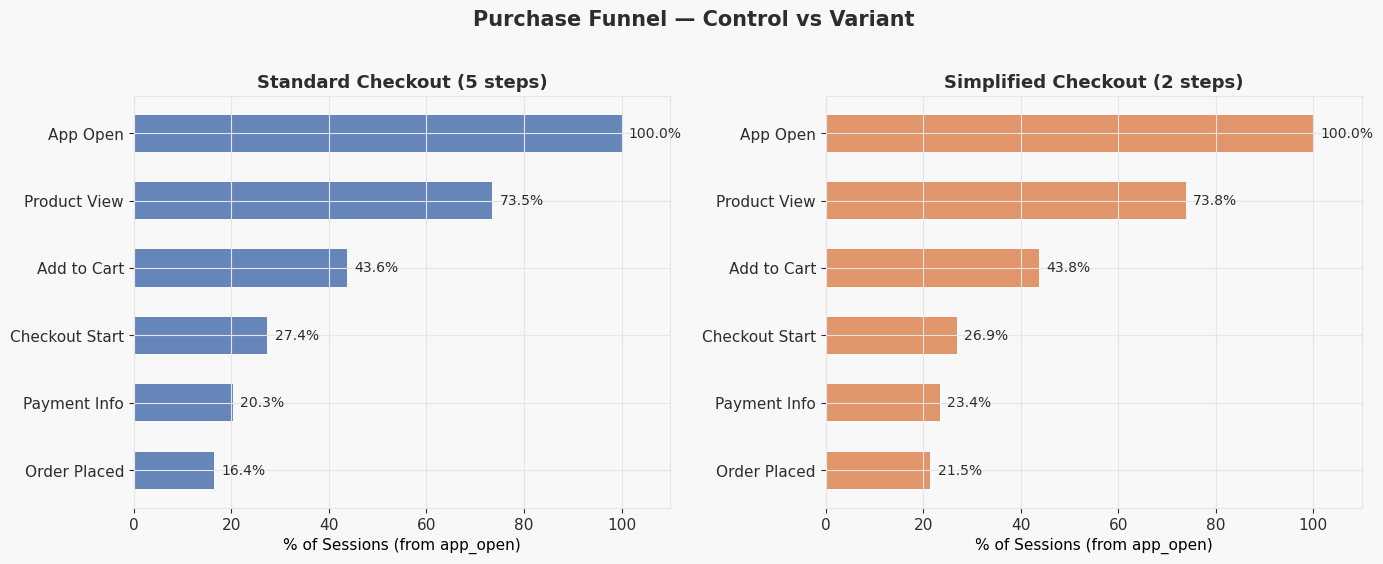

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Purchase Funnel — Control vs Variant', fontsize=15, fontweight='bold', y=1.02)

for ax, grp, color in zip(axes, ['control', 'variant'], [CTRL_COLOR, VAR_COLOR]):
    pcts = [funnel_data[grp][s]['pct_of_top'] for s in stages]
    lbls = [stage_labels[s] for s in stages]
    bars = ax.barh(lbls[::-1], pcts[::-1], color=color, alpha=0.85, height=0.55)
    ax.set_xlim(0, 110)
    ax.set_xlabel('% of Sessions (from app_open)')
    ax.set_title(f"{'Standard Checkout (5 steps)' if grp == 'control' else 'Simplified Checkout (2 steps)'}")
    for bar, pct in zip(bars, pcts[::-1]):
        ax.text(pct + 1.5, bar.get_y() + bar.get_height() / 2,
                f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 4. Primary Metric — Purchase Conversion Rate

CVR = unique users who placed an order ÷ unique users who opened the app (entered funnel). This is our headline metric for the test.

In [8]:
# ── user-level CVR ─────────────────────────────────────────────────────────
grp_users  = funnel.groupby('ab_group')['user_id'].nunique()
grp_orders = orders.groupby('ab_group')['user_id'].nunique()

ctrl_u, ctrl_c = int(grp_users['control']),  int(grp_orders['control'])
var_u,  var_c  = int(grp_users['variant']),  int(grp_orders['variant'])

ctrl_r = ctrl_c / ctrl_u
var_r  = var_c  / var_u
lift   = (var_r - ctrl_r) / ctrl_r * 100

# ── z-test for proportions (manual, no statsmodels needed) ──────────────────
def prop_ztest_ci(x1, n1, x2, n2, alpha=0.05):
    p1, p2   = x1 / n1, x2 / n2
    p_pool   = (x1 + x2) / (n1 + n2)
    se       = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z        = (p2 - p1) / se
    p_val    = 2 * (1 - stats.norm.cdf(abs(z)))
    z_crit   = stats.norm.ppf(1 - alpha / 2)
    ci1 = (p1 - z_crit * np.sqrt(p1*(1-p1)/n1),  p1 + z_crit * np.sqrt(p1*(1-p1)/n1))
    ci2 = (p2 - z_crit * np.sqrt(p2*(1-p2)/n2),  p2 + z_crit * np.sqrt(p2*(1-p2)/n2))
    return z, p_val, ci1, ci2

z, p_val, ci_ctrl, ci_var = prop_ztest_ci(ctrl_c, ctrl_u, var_c, var_u)

print("=" * 55)
print("  PRIMARY METRIC: Purchase Conversion Rate")
print("=" * 55)
print(f"  Control : {ctrl_r*100:.2f}%  (95% CI: {ci_ctrl[0]*100:.2f}% – {ci_ctrl[1]*100:.2f}%)")
print(f"  Variant : {var_r*100:.2f}%  (95% CI: {ci_var[0]*100:.2f}% – {ci_var[1]*100:.2f}%)")
print(f"  Lift    : +{lift:.2f}%")
print(f"  z-stat  : {z:.3f}   p-value: {p_val:.2e}")
print(f"  Result  : {'  STATISTICALLY SIGNIFICANT (p < 0.05)' if p_val < 0.05 else '❌  Not significant'}")
print("=" * 55)

  PRIMARY METRIC: Purchase Conversion Rate
  Control : 28.90%  (95% CI: 27.56% – 30.24%)
  Variant : 36.34%  (95% CI: 34.92% – 37.76%)
  Lift    : +25.77%
  z-stat  : 7.448   p-value: 9.48e-14
  Result  :   STATISTICALLY SIGNIFICANT (p < 0.05)


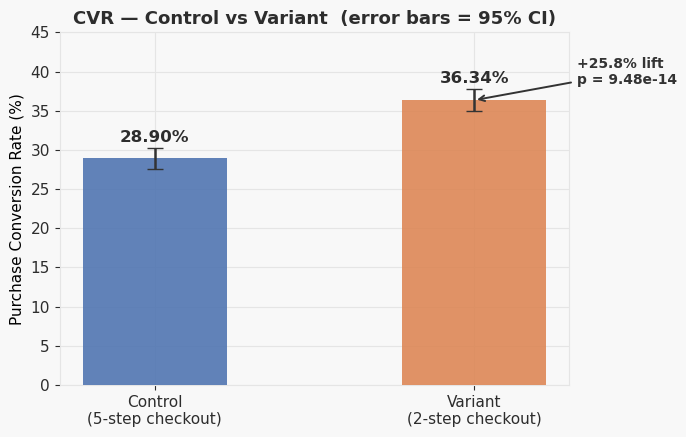

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))

rates  = [ctrl_r * 100, var_r * 100]
errors = [(ctrl_r - ci_ctrl[0]) * 100, (var_r - ci_var[0]) * 100]
colors = [CTRL_COLOR, VAR_COLOR]
labels = ['Control\n(5-step checkout)', 'Variant\n(2-step checkout)']
bars   = ax.bar(labels, rates, color=colors, width=0.45, alpha=0.88, zorder=3)

ax.errorbar(labels, rates, yerr=errors, fmt='none',
            color='#333', capsize=6, linewidth=1.8, zorder=4)

for bar, rate, ci in zip(bars, rates, [ci_ctrl, ci_var]):
    ax.text(bar.get_x() + bar.get_width()/2, rate + errors[0] + 0.8,
            f'{rate:.2f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, 45)
ax.set_ylabel('Purchase Conversion Rate (%)')
ax.set_title('CVR — Control vs Variant  (error bars = 95% CI)')

# lift annotation
ax.annotate(f'+{lift:.1f}% lift\np = {p_val:.2e}',
            xy=(1, var_r * 100), xytext=(1.32, var_r * 100 + 2),
            fontsize=10, color='#333', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#333', lw=1.4))

plt.tight_layout()
plt.show()

## 5. Secondary Metrics — Revenue, AOV, Returns

A higher CVR is great, but not if it comes at the cost of order quality. Let's check whether the simplification changed what people buy or whether they return more.

In [11]:
ctrl_ord = orders[orders['ab_group'] == 'control']['order_value_eur']
var_ord  = orders[orders['ab_group'] == 'variant']['order_value_eur']

ctrl_rev_pu = ctrl_ord.sum() / ctrl_u
var_rev_pu  = var_ord.sum()  / var_u
rev_lift    = (var_rev_pu - ctrl_rev_pu) / ctrl_rev_pu * 100

t_stat, p_aov = stats.ttest_ind(ctrl_ord, var_ord)

ctrl_ret = orders[orders['ab_group']=='control']['is_returned'].mean()
var_ret  = orders[orders['ab_group']=='variant']['is_returned'].mean()

_, p_ret, _, _ = prop_ztest_ci(
    int(orders[orders['ab_group']=='control']['is_returned'].sum()), len(ctrl_ord),
    int(orders[orders['ab_group']=='variant']['is_returned'].sum()), len(var_ord)
)

print(f"{'Metric':<28} {'Control':>12} {'Variant':>12} {'Δ':>10}  {'Sig?':>6}")
print("─" * 74)
print(f"  {'Revenue per User':<26} €{ctrl_rev_pu:>10.2f} €{var_rev_pu:>10.2f}  +{rev_lift:>6.1f}%   ─")
print(f"  {'Avg Order Value (AOV)':<26} €{ctrl_ord.mean():>10.2f} €{var_ord.mean():>10.2f}  {(var_ord.mean()-ctrl_ord.mean())/ctrl_ord.mean()*100:>6.1f}%   {'✅' if p_aov<0.05 else '✗ n.s.'}")
print(f"  {'Median Order Value':<26} €{ctrl_ord.median():>10.2f} €{var_ord.median():>10.2f}  {(var_ord.median()-ctrl_ord.median())/ctrl_ord.median()*100:>6.1f}%   ─")
print(f"  {'Return Rate':<26}  {ctrl_ret*100:>10.1f}%  {var_ret*100:>10.1f}%  {(var_ret-ctrl_ret)*100:>+5.1f}pp   {'' if p_ret<0.05 else '✗ n.s.'}")
print(f"  {'Total Orders':<26}  {len(ctrl_ord):>11,}  {len(var_ord):>11,}   ─")
print()
print(f"  AOV t-test: t = {t_stat:.3f}, p = {p_aov:.3f}  → AOV difference is NOT significant → guardrail holds ")

Metric                            Control      Variant          Δ    Sig?
──────────────────────────────────────────────────────────────────────────
  Revenue per User           €     50.82 €     65.04  +  28.0%   ─
  Avg Order Value (AOV)      €    156.24 €    152.48    -2.4%   ✗ n.s.
  Median Order Value         €    158.28 €    147.75    -6.7%   ─
  Return Rate                       15.2%        14.9%   -0.4pp   ✗ n.s.
  Total Orders                      1,425        1,885   ─

  AOV t-test: t = 1.274, p = 0.203  → AOV difference is NOT significant → guardrail holds 


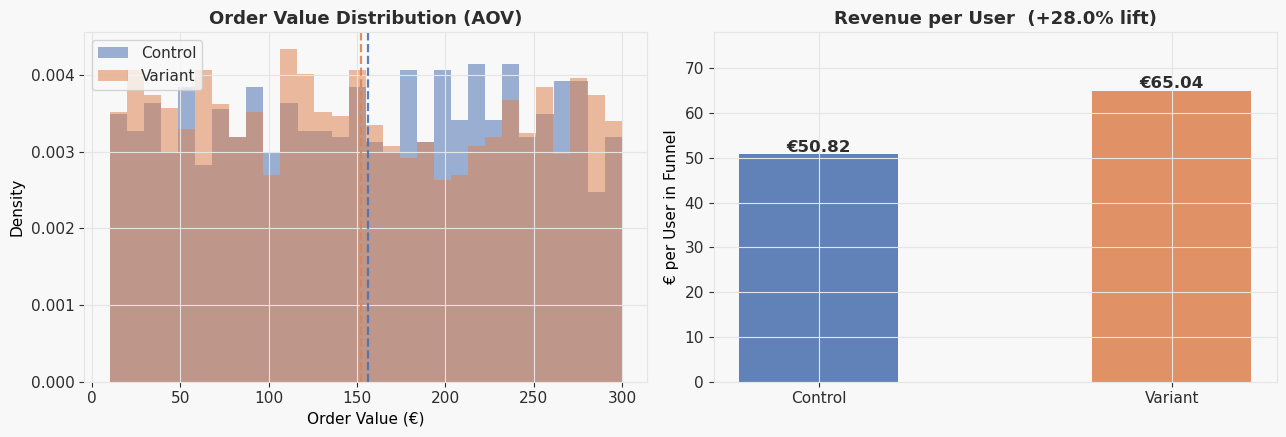

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: AOV distribution
for arr, lbl, color in [(ctrl_ord, 'Control', CTRL_COLOR), (var_ord, 'Variant', VAR_COLOR)]:
    axes[0].hist(arr, bins=30, alpha=0.55, color=color, label=lbl, density=True)
    axes[0].axvline(arr.mean(), color=color, linestyle='--', linewidth=1.6, alpha=0.9)
axes[0].set_title('Order Value Distribution (AOV)')
axes[0].set_xlabel('Order Value (€)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: Revenue per user bar
rev_vals  = [ctrl_rev_pu, var_rev_pu]
rev_label = ['Control', 'Variant']
bars = axes[1].bar(rev_label, rev_vals, color=[CTRL_COLOR, VAR_COLOR], width=0.45, alpha=0.88)
for bar, v in zip(bars, rev_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'€{v:.2f}',
                 ha='center', fontsize=12, fontweight='bold')
axes[1].set_title(f'Revenue per User  (+{rev_lift:.1f}% lift)')
axes[1].set_ylabel('€ per User in Funnel')
axes[1].set_ylim(0, max(rev_vals) * 1.2)

plt.tight_layout()
plt.show()

## 6. Checkout Funnel Deep-Dive

The biggest story is in the checkout sub-funnel. Even though both groups started checkout at similar rates (~27%), the variant converts at a dramatically higher rate once someone begins checkout. That's the friction we expected to remove.

In [14]:
# checkout_start → order_placed by group
checkout_metrics = {}
for grp in ['control', 'variant']:
    sub  = funnel[funnel['ab_group'] == grp]
    sess = sub.groupby('session_id')['stage'].apply(set)
    cs   = sess.apply(lambda x: 'checkout_start' in x).sum()
    pi   = sess.apply(lambda x: 'payment_info'   in x).sum()
    op   = sess.apply(lambda x: 'order_placed'    in x).sum()
    checkout_metrics[grp] = {'checkout_start': cs, 'payment_info': pi, 'order_placed': op}

for grp, m in checkout_metrics.items():
    cs, pi, op = m['checkout_start'], m['payment_info'], m['order_placed']
    print(f"  {grp.upper()} — {cs:,} started checkout")
    print(f"    → payment_info : {pi:,}  ({pi/cs*100:.1f}% of starters)")
    print(f"    → order_placed : {op:,}  ({op/cs*100:.1f}% of starters)")
    print()

ctrl_cs = checkout_metrics['control']['checkout_start']
var_cs  = checkout_metrics['variant']['checkout_start']
ctrl_op = checkout_metrics['control']['order_placed']
var_op  = checkout_metrics['variant']['order_placed']

z_co, p_co, _, _ = prop_ztest_ci(ctrl_op, ctrl_cs, var_op, var_cs)
print(f"Checkout completion rate — z={z_co:.3f}, p={p_co:.2e}  → {' Significant' if p_co<0.05 else 'Not significant'}")

  CONTROL — 2,373 started checkout
    → payment_info : 1,762  (74.3% of starters)
    → order_placed : 1,425  (60.1% of starters)

  VARIANT — 2,356 started checkout
    → payment_info : 2,051  (87.1% of starters)
    → order_placed : 1,885  (80.0% of starters)

Checkout completion rate — z=14.974, p=0.00e+00  →  Significant


## 7. Segment Analysis — Does the Variant Win Everywhere?

Segment breakdowns tell us whether the effect is consistent or whether it's driven by a specific cohort. This matters for roll-out decisions and for understanding *who* benefits most.

In [15]:
# ── helper ──────────────────────────────────────────────────────────────────
def seg_cvr(seg_col, seg_vals, funnel_df, orders_df, users_df=None):
    rows = []
    for val in seg_vals:
        for grp in ['control', 'variant']:
            if seg_col in funnel_df.columns:
                u = funnel_df[(funnel_df[seg_col]==val) & (funnel_df['ab_group']==grp)]['user_id'].nunique()
                o = orders_df[(orders_df[seg_col]==val) & (orders_df['ab_group']==grp)]['user_id'].nunique()
            else:  # age_group — need user join
                uid_pool = users_df[users_df[seg_col]==val]['user_id']
                u = funnel_df[funnel_df['user_id'].isin(uid_pool) & (funnel_df['ab_group']==grp)]['user_id'].nunique()
                o = orders_df[orders_df['user_id'].isin(uid_pool) & (orders_df['ab_group']==grp)]['user_id'].nunique()
            cvr = o / u if u > 0 else 0
            rows.append({'segment': val, 'group': grp, 'users': u, 'orders': o, 'cvr': cvr})
    df = pd.DataFrame(rows)
    pivot = df.pivot(index='segment', columns='group', values='cvr').mul(100).round(1)
    pivot['lift_pp'] = (pivot['variant'] - pivot['control']).round(1)
    pivot['lift_pct'] = ((pivot['variant'] - pivot['control']) / pivot['control'] * 100).round(1)
    return pivot

print("=== CVR by Device ===")
print(seg_cvr('device', ['iOS','Android'], funnel, orders).to_string())

print("\n=== CVR by Country ===")
print(seg_cvr('country', ['DE','PL','CZ','SK','RO'], funnel, orders).to_string())

print("\n=== CVR by Age Group ===")
print(seg_cvr('age_group', ['18-24','25-34','35-44','45-54','55+'], funnel, orders, users).to_string())

=== CVR by Device ===
group    control  variant  lift_pp  lift_pct
segment                                     
Android     27.9     35.0      7.1      25.4
iOS         30.4     38.4      8.0      26.3

=== CVR by Country ===
group    control  variant  lift_pp  lift_pct
segment                                     
CZ          29.1     34.0      4.9      16.8
DE          34.5     44.0      9.5      27.5
PL          28.2     36.0      7.8      27.7
RO          20.4     20.7      0.3       1.5
SK          16.9     25.3      8.4      49.7

=== CVR by Age Group ===
group    control  variant  lift_pp  lift_pct
segment                                     
18-24       30.2     35.9      5.7      18.9
25-34       29.5     36.6      7.1      24.1
35-44       27.8     39.0     11.2      40.3
45-54       28.4     36.1      7.7      27.1
55+         28.7     34.2      5.5      19.2


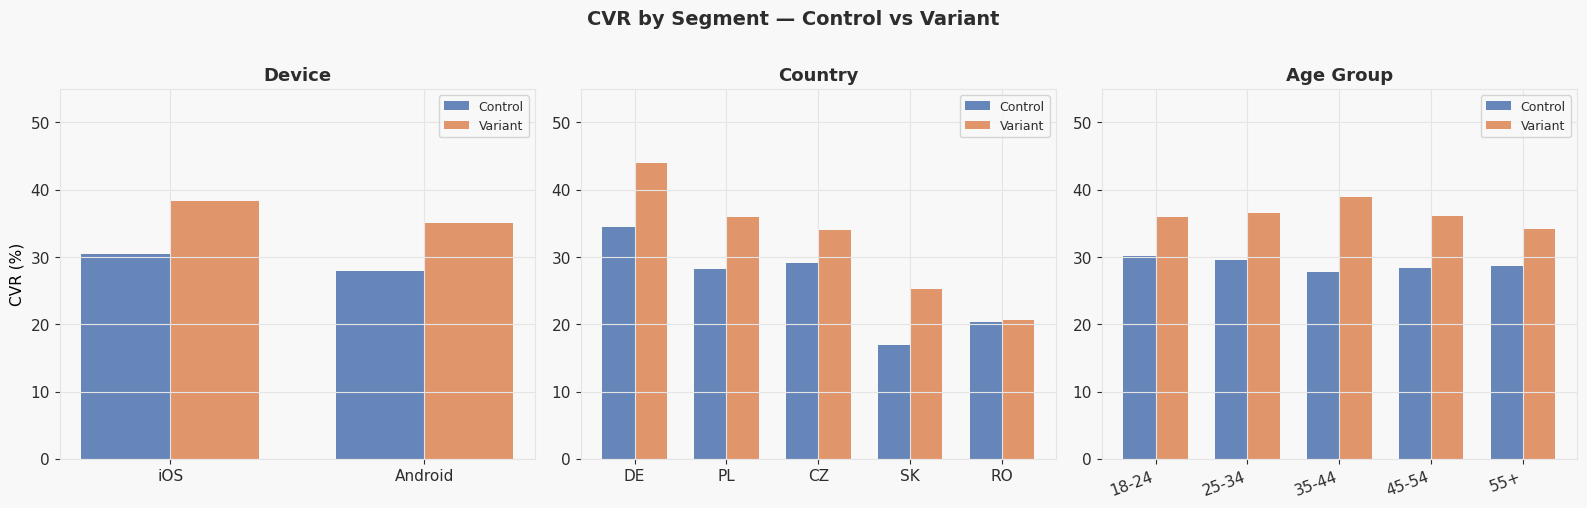

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('CVR by Segment — Control vs Variant', fontsize=14, fontweight='bold', y=1.01)

seg_specs = [
    ('device',    ['iOS','Android'],             'Device'),
    ('country',   ['DE','PL','CZ','SK','RO'],    'Country'),
    ('age_group', ['18-24','25-34','35-44','45-54','55+'], 'Age Group'),
]

for ax, (seg_col, seg_vals, title) in zip(axes, seg_specs):
    if seg_col == 'age_group':
        df = seg_cvr(seg_col, seg_vals, funnel, orders, users)
    else:
        df = seg_cvr(seg_col, seg_vals, funnel, orders)

    x = np.arange(len(seg_vals))
    w = 0.35
    ax.bar(x - w/2, df.loc[seg_vals, 'control'], w, label='Control', color=CTRL_COLOR, alpha=0.85)
    ax.bar(x + w/2, df.loc[seg_vals, 'variant'], w, label='Variant',  color=VAR_COLOR,  alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(seg_vals, rotation=20 if seg_col=='age_group' else 0, ha='right' if seg_col=='age_group' else 'center')
    ax.set_title(title)
    ax.set_ylabel('CVR (%)' if ax == axes[0] else '')
    ax.set_ylim(0, 55)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8.  Notable Finding — Romania Flat Response

Romania is the one country where the variant shows virtually **no lift** (~+0.3pp vs +9pp elsewhere). This is worth flagging to the team — possible causes include payment method mismatch, localisation gaps in the new checkout screen, or a different user profile. I'd recommend a follow-up deep-dive with the local team.

In [18]:
# Romania deep-dive
ro_funnel  = funnel[funnel['country'] == 'RO']
ro_orders  = orders[orders['country'] == 'RO']

print("RO — funnel stages by group")
for grp in ['control','variant']:
    sub  = ro_funnel[ro_funnel['ab_group']==grp]
    sess = sub.groupby('session_id')['stage'].apply(set)
    print(f"  {grp}")
    for s in ['checkout_start','payment_info','order_placed']:
        n = sess.apply(lambda x: s in x).sum()
        base = sess.apply(lambda x: 'checkout_start' in x).sum()
        if base > 0:
            print(f"    {s}: {n}  ({n/base*100:.1f}% of checkout starters)")

print()
# Avg time on payment_info for RO
ro_pay = funnel[(funnel['country']=='RO') & (funnel['stage']=='payment_info')]
print("RO — Avg time on payment_info (sec)")
print(ro_pay.groupby('ab_group')['time_on_stage_sec'].mean().round(1))
print()
print("  Hypothesis: RO users spend more time on payment_info in variant → possible UX confusion or missing local payment method")

RO — funnel stages by group
  control
    checkout_start: 165  (100.0% of checkout starters)
    payment_info: 121  (73.3% of checkout starters)
    order_placed: 97  (58.8% of checkout starters)
  variant
    checkout_start: 149  (100.0% of checkout starters)
    payment_info: 121  (81.2% of checkout starters)
    order_placed: 97  (65.1% of checkout starters)

RO — Avg time on payment_info (sec)
ab_group
control    152.8
variant    156.0
Name: time_on_stage_sec, dtype: float64

  Hypothesis: RO users spend more time on payment_info in variant → possible UX confusion or missing local payment method


## 9. Summary & Recommendation

### What the data tells us

| Metric | Control | Variant | Change | Significance |
|---|---|---|---|---|
| Purchase CVR | 28.9% | 36.3% | **+25.8% lift** |  p < 0.001 |
| Revenue per User | €50.82 | €65.04 | **+28.0%** | — |
| AOV | €156.24 | €152.48 | -2.4% | ✗ n.s. (guardrail holds) |
| Return Rate | 15.2% | 14.9% | -0.3pp | ✗ n.s. |
| Checkout completion | 60.1% | 80.0% | **+19.9pp** |  p < 0.001 |

### My recommendation

**Ship the variant globally — with one exception.**

The simplified 2-step checkout is a clear win. The +25.8% CVR lift is statistically significant and economically meaningful: revenue per user is up +28% with no degradation in order quality (AOV and return rate are unchanged). The effect holds consistently across devices, age groups, and most countries.

**Romania exception:** Hold the rollout for RO while we investigate the flat response. I recommend a 2-week qualitative sprint with the local product/ops team to understand whether it's a payment method, a translation/copy issue, or something else entirely.

### Next steps

1. **Merge & release** the 2-step checkout for DE, PL, CZ, SK
2. **RO investigation** — qualitative sessions + CS ticket analysis
3. **Monitor post-launch** CVR, AOV, and return rate weekly for 4 weeks
4. **Follow-up test idea:** Now that checkout friction is reduced, the next bottleneck is add_to_cart → checkout_start (only ~62% proceed). Worth testing a persistent cart summary bar or a simplified PDP CTA.

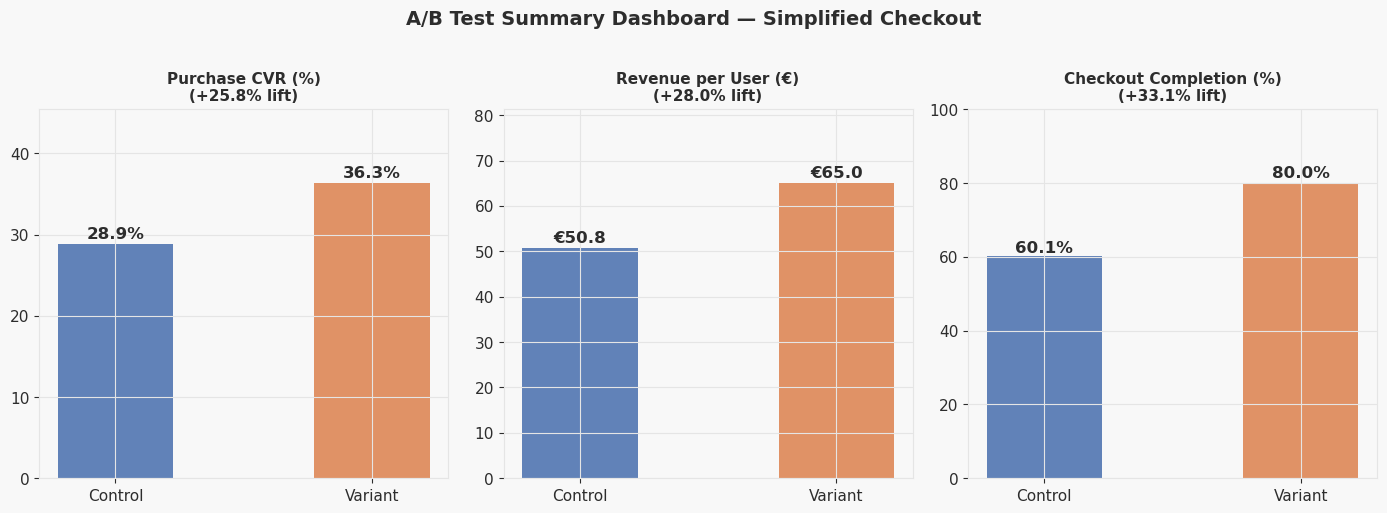


  Analysis complete. Variant wins — recommend shipping to all markets except RO pending investigation.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('A/B Test Summary Dashboard — Simplified Checkout', fontsize=14, fontweight='bold', y=1.02)

# CVR
metrics = {
    'Purchase CVR (%)':        ([ctrl_r*100, var_r*100],     ''),
    'Revenue per User (€)':    ([ctrl_rev_pu, var_rev_pu],  '€'),
    'Checkout Completion (%)': ([60.1, 80.0],               ''),
}
for ax, (title, (vals, prefix)) in zip(axes, metrics.items()):
    bars = ax.bar(['Control', 'Variant'], vals, color=[CTRL_COLOR, VAR_COLOR], width=0.45, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v*1.02,
                f'{prefix}{v:.1f}{"%" if "%" in title else ""}',
                ha='center', fontsize=12, fontweight='bold')
    lift_val = (vals[1]-vals[0])/vals[0]*100
    ax.set_title(f'{title}\n(+{lift_val:.1f}% lift)', fontsize=11)
    ax.set_ylim(0, max(vals)*1.25)

plt.tight_layout()
plt.show()
print("\n  Analysis complete. Variant wins — recommend shipping to all markets except RO pending investigation.")